<p style="font-size:19px; text-align:left;"><i>Advanced Applications of Generative AI in Actuarial Science: Case Studies Beyond ChatGPT</i></p>
<p style="font-size:25px; text-align:left; font-weight:bold;">Case Study: Actuarial Legacy Code Migration Multi-Agent System</p>
<p style="font-size:19px; text-align:left; margin-top: -10px; margin-bottom: 15px;">Simon Hatzesberger (<a href="mailto:simon.hatzesberger@gmail.com">simon.hatzesberger@gmail.com</a>), Iris Nonneman (<a href="mailto:irisnonneman@gmail.com">irisnonneman@gmail.com</a>)
<p style="font-style:italic; font-size: 19px">Date: April 15, 2026</p>

<p>
<a href="https://colab.research.google.com/github/IAA-AITF/Actuarial-AI-Case-Studies/blob/main/case-studies/2026/actuarial_legacy_code_migration_multi-agent_system/R_to_Python_Migration.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" />
</a>&nbsp;
<a href="https://kaggle.com/kernels/welcome?src=https://github.com/IAA-AITF/Actuarial-AI-Case-Studies/blob/main/case-studies/2026/actuarial_legacy_code_migration_multi-agent_system/R_to_Python_Migration.ipynb">
  <img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open In Kaggle" />
</a>
</p>

In [1]:
# ── Cloud Environment Setup ──────────────────────────────────────────────────
# Detect if running in Google Colab or Kaggle and install required packages.

import os, sys

IN_COLAB = "google.colab" in sys.modules
IN_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IN_COLAB or IN_KAGGLE:
    %pip install -q langchain langgraph langchain-openai statsmodels
    print("Packages installed for cloud environment.")
else:
    print("Local environment detected. Ensure packages are installed via requirements.txt.")

Local environment detected. Ensure packages are installed via requirements.txt.


<h1 style="font-size:22px; background-color: #E6E6E6; color: black; height: 50px; line-height: 50px; padding-left: 14px;">Table of Contents</h1>

[1. Overview and Key Takeaways](#overview_and_key_takeaways)

[2. Environment Setup](#environment_setup)

[3. Actuarial Legacy Code Migration System](#migration_system)  
&emsp;&emsp;&emsp;[3.1 Tool Definitions](#tool_definitions)  
&emsp;&emsp;&emsp;[3.2 Agent Definitions](#agent_definitions)  
&emsp;&emsp;&emsp;[3.3 Workflow Graph](#workflow_graph)

[4. Simple Example – Chain Ladder Reserving](#simple_example)  
&emsp;&emsp;&emsp;[4.1 Input](#simple_input)  
&emsp;&emsp;&emsp;[4.2 Migration Pipeline](#simple_pipeline)  
&emsp;&emsp;&emsp;[4.3 Outputs](#simple_outputs)

[5. Difficult Example – GLM-Based Reserving with Bootstrap](#difficult_example)  
&emsp;&emsp;&emsp;[5.1 Input](#difficult_input)  
&emsp;&emsp;&emsp;[5.2 Migration Pipeline](#difficult_pipeline)  
&emsp;&emsp;&emsp;[5.3 Outputs](#difficult_outputs)

[6. Benchmarking](#benchmarking)


<h1 id="overview_and_key_takeaways" style="font-size:22px; background-color: #E6E6E6; color: black; height: 50px; line-height: 50px; padding-left: 14px;">1. Overview and Key Takeaways</h1>

Many actuarial organizations maintain legacy codebases written in R (or SAS, COBOL, VBA) that perform critical tasks such as claims reserving, mortality modeling, and pricing. As organizations modernize their technology stacks, migrating these codebases to Python becomes increasingly important – but manual translation is time-consuming, error-prone, and requires expertise in both languages, as well as domain knowledge.

This case study demonstrates how a **multi-agent system** powered by Large Language Models (LLMs) can automate the migration of actuarial R code to Python. Rather than relying on a single LLM call, we decompose the migration task into specialized sub-tasks, each handled by a dedicated agent:

- An **R Analysis Agent** that reads and analyzes the source code to guide the Translation Agent.
- A **Translation Agent** that converts the R code into idiomatic Python.
- A **Compilation Agent** that validates the translated code compiles and runs.
- A **Test Runner Agent** that executes a prespecified test suite against the translated code.
- A **Report Agent** that documents the entire migration process.

The test suite itself is **not** generated by the R Analysis Agent; it is prepared manually in advance and shipped with the notebook so that every run is evaluated against the same comparability-preserving benchmark.

A **LangGraph StateGraph** orchestrates these agents in a defined workflow with hardcoded edges, including conditional retry loops that automatically re-invoke the Translation Agent when compilation or tests fail.

**Key Takeaways:**

- **Multi-agent systems decompose complex tasks** into manageable, specialized sub-tasks that individual LLM agents can handle more reliably.
- **LangGraph** provides a robust framework for orchestrating agent workflows with conditional routing and feedback loops.
- **Automated testing is essential** for validating code translations – the system uses both data/format tests and content/numerical tests.
- **Feedback loops enable self-correction**: when the translated code fails compilation or tests, the system automatically retries with error context.
- **The approach is language-agnostic**: while this case study focuses on R-to-Python, the same architecture applies to SAS, VBA, or other source and target languages.

The notebook concludes with a **Benchmarking** section (Section 6) that repeats each of the two examples 10 times independently to quantify robustness and output stability.


<h1 id="environment_setup" style="font-size:22px; background-color: #E6E6E6; color: black; height: 50px; line-height: 50px; padding-left: 14px;">2. Environment Setup</h1>

We begin by importing the required libraries and configuring the OpenAI API key. The system uses:

- **LangChain** for agent creation and tool definitions
- **LangGraph**  for multi-agent orchestration with hardcoded workflow edges
- **OpenAI** models (GPT-5.4 and GPT-5.4 mini) as the underlying LLMs
- Standard Python libraries for file I/O, syntax checking, and subprocess execution

The API key is read from the environment variable `OPENAI_API_KEY`. If not set, you will be prompted to enter it.

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────

import os
import re
import ast
import sys
import json
import subprocess
import getpass
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from typing import Annotated
from typing_extensions import TypedDict

# LangChain / LangGraph
from langchain_core.tools import tool
from langchain.agents import create_agent
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# Display
import pandas as pd
from IPython.display import Markdown, Image, display

In [3]:
# ── Environment Setup ────────────────────────────────────────────────────────

import shutil, glob

def _set_if_undefined(var: str):
    """Prompt for and set an environment variable if not already defined."""
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"Please provide your {var}: ")

_set_if_undefined("OPENAI_API_KEY")

# Working directory (notebook location)
NOTEBOOK_DIR = os.getcwd()
OUTPUT_DIR = os.path.join(NOTEBOOK_DIR, "output")
os.makedirs(os.path.join(OUTPUT_DIR, "translated"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "tests"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "reports"), exist_ok=True)

def _rel_path(abs_path):
    """Convert an absolute path to a path relative to the notebook directory."""
    try:
        return os.path.relpath(abs_path, NOTEBOOK_DIR)
    except ValueError:
        return abs_path

def _find_rscript():
    """Find Rscript executable: check PATH first, then common Windows install dirs."""
    found = shutil.which("Rscript")
    if found:
        return found
    # Check standard Windows R installation paths
    for pattern in [
        os.path.join("C:" + os.sep, "Program Files", "R", "R-*", "bin", "Rscript.exe"),
        os.path.join("C:" + os.sep, "Program Files (x86)", "R", "R-*", "bin", "Rscript.exe"),
    ]:
        matches = sorted(glob.glob(pattern), reverse=True)  # newest version first
        if matches:
            return matches[0]
    return None


<h1 id="migration_system" style="font-size:22px; background-color: #E6E6E6; color: black; height: 50px; line-height: 50px; padding-left: 14px;">3. Actuarial Legacy Code Migration System</h1>

This section implements the multi-agent migration system end-to-end: we first define the tools each agent can invoke, then specify the five agents themselves, and finally wire them together with a LangGraph StateGraph. Subsequent sections apply the resulting pipeline to two progressively more complex R examples.

The system is implemented on a **LangGraph StateGraph** with hardcoded sequential edges and conditional retry loops, orchestrating five specialized agents:

1. **R Analysis Agent** analyzes the R source code and produces a structured summary for the Translation Agent.
2. **Translation Agent** converts R code to Python.
3. **Compilation Agent** checks syntax and runs the translated file.
4. **Test Runner Agent** executes the pytest suite.
5. **Report Agent** writes the migration report.

The table below summarizes each agent, the LLM model it uses, and the tools available to it:

| Agent | Model | Role | Tools |
|:---|:---|:---|:---|
| **R Analysis Agent** | GPT-5.4 | Reads R source code and data files and returns a structured summary (functions, data shapes, libraries, expected outputs) that guides the Translation Agent | `read_file`, `read_csv_preview`, `run_r_code` |
| **Translation Agent** | GPT-5.4 | Translates R code to idiomatic Python; handles library mappings (data.frame to pandas, matrix to numpy, etc.) | `read_file`, `split_r_code`, `write_translated_file` |
| **Compilation Agent** | GPT-5.4 mini | Validates Python syntax via `ast.parse()` and executes the translated file in a subprocess | `read_file`, `check_syntax`, `run_python_file` |
| **Test Runner Agent** | GPT-5.4 mini | Runs the pytest test suite and reports structured results per test (name, category, expected, status) | `read_file`, `run_tests` |
| **Report Agent** | GPT-5.4 mini | Writes a detailed Markdown migration report covering approach, challenges, agent execution log, and test results | `read_file`, `write_file` |

<h1 id="tool_definitions" style="font-size:20px; font-weight:bold;">3.1 Tool Definitions</h1>
<hr>

In LangGraph, **tools** are Python functions that agents can invoke to interact with the outside world – reading files, writing code, executing programs, or running tests. Each tool is decorated with `@tool` and includes a docstring that the LLM uses to decide when and how to call it.

We define two groups of tools:

1. **File I/O tools**: read/write files, preview CSV data, write translated output
2. **Code analysis tools**: split large R code, check Python syntax, execute files, run pytest

In [4]:
# ── File I/O Tools ───────────────────────────────────────────────────────────

@tool
def read_file(path: str) -> str:
    """Read and return the contents of a file at the given path.
    Use this to read R source files, Python files, CSV files, or any text file."""
    try:
        if not os.path.isabs(path):
            path = os.path.join(NOTEBOOK_DIR, path)
        with open(path, "r", encoding="utf-8") as f:
            return f.read()
    except Exception as e:
        return f"Error reading file: {e}"


@tool
def write_file(content: str, path: str) -> str:
    """Write content to a file at the given path.
    Creates parent directories if needed. Returns the relative path written."""
    try:
        if not os.path.isabs(path):
            path = os.path.join(NOTEBOOK_DIR, path)
        os.makedirs(os.path.dirname(path), exist_ok=True)
        with open(path, "w", encoding="utf-8") as f:
            f.write(content)
        return f"File written successfully to: {_rel_path(path)}"
    except Exception as e:
        return f"Error writing file: {e}"


@tool
def read_csv_preview(path: str, n: int = 10) -> str:
    """Return the first n rows of a CSV file as a formatted string.
    Useful for understanding the structure and content of data files."""
    try:
        if not os.path.isabs(path):
            path = os.path.join(NOTEBOOK_DIR, path)
        df = pd.read_csv(path, nrows=n)
        return f"Shape: {df.shape}\nColumns: {list(df.columns)}\n\n{df.to_string()}"
    except Exception as e:
        return f"Error reading CSV: {e}"


@tool
def write_translated_file(content: str, filename: str) -> str:
    """Write content to a file in the output/translated/ directory ONLY.
    The filename should be just the basename, e.g. 'chain_ladder.py'.
    Returns the relative path written."""
    try:
        safe_name = os.path.basename(filename)
        path = os.path.join(NOTEBOOK_DIR, "output", "translated", safe_name)
        os.makedirs(os.path.dirname(path), exist_ok=True)
        with open(path, "w", encoding="utf-8") as f:
            f.write(content)
        return f"File written successfully to: {_rel_path(path)}"
    except Exception as e:
        return f"Error writing file: {e}"

The next group of tools handles **code analysis and execution**. These enable agents to split large R files into chunks, validate Python syntax without running the code, execute translated files in a subprocess, and run the pytest test suite with structured reporting.

The `run_tests` tool integrates with a custom `conftest.py` plugin (in `output/tests/`) that writes a JSON report capturing each test's name, description, category (data vs. content), expected value, and pass/fail status.

In [5]:
# ── Code Analysis and Execution Tools ────────────────────────────────────────

@tool
def split_r_code(code: str, max_lines: int = 200) -> str:
    """Split R code into logical chunks if it exceeds max_lines.
    Splits on function boundaries (lines matching '<- function').
    Returns a JSON list of code chunks."""
    lines = code.split("\n")
    if len(lines) <= max_lines:
        return json.dumps([code])
    func_starts = [i for i, line in enumerate(lines) if re.search(r"<-\s*function", line)]
    if not func_starts:
        mid = len(lines) // 2
        return json.dumps(["\n".join(lines[:mid]), "\n".join(lines[mid:])])
    preamble = "\n".join(lines[:func_starts[0]])
    chunks = [preamble] if preamble.strip() else []
    for idx, start in enumerate(func_starts):
        end = func_starts[idx + 1] if idx + 1 < len(func_starts) else len(lines)
        chunks.append("\n".join(lines[start:end]))
    return json.dumps(chunks)


@tool
def check_syntax(code: str) -> str:
    """Check Python code for syntax errors using ast.parse().
    Returns 'SYNTAX_OK' or a detailed error message."""
    try:
        ast.parse(code)
        return "SYNTAX_OK"
    except SyntaxError as e:
        return f"SYNTAX_ERROR: Line {e.lineno}, Column {e.offset}: {e.msg}"


@tool
def run_python_file(path: str, timeout: int = 300) -> str:
    """Execute a Python file in a subprocess with a timeout.
    Returns stdout/stderr combined with success/failure status."""
    try:
        if not os.path.isabs(path):
            path = os.path.join(NOTEBOOK_DIR, path)
        cwd = os.path.dirname(path)
        result = subprocess.run(
            [sys.executable, path], capture_output=True, text=True,
            timeout=timeout, cwd=cwd,
            encoding="utf-8", errors="replace",
        )
        output = ""
        if result.stdout:
            lines = result.stdout.strip().split("\n")
            if len(lines) > 50:
                output += f"STDOUT (last 50 of {len(lines)} lines):\n"
                output += "\n".join(lines[-50:]) + "\n"
            else:
                output += f"STDOUT:\n{result.stdout}\n"
        if result.stderr:
            err_lines = result.stderr.strip().split("\n")
            if len(err_lines) > 50:
                output += f"STDERR (last 50 of {len(err_lines)} lines):\n"
                output += "\n".join(err_lines[-50:]) + "\n"
            else:
                output += f"STDERR:\n{result.stderr}\n"
        status = "EXECUTION_SUCCESS" if result.returncode == 0 else f"EXECUTION_FAILED (exit code {result.returncode})"
        return f"{status}\n{output}"
    except subprocess.TimeoutExpired:
        return f"EXECUTION_TIMEOUT: Script did not finish within {timeout} seconds."
    except Exception as e:
        return f"EXECUTION_ERROR: {e}"


@tool
def run_tests(test_path: str) -> str:
    """Run pytest on the given test file and return structured results.
    Reads the JSON report produced by conftest.py for per-test details."""
    try:
        if not os.path.isabs(test_path):
            test_path = os.path.join(NOTEBOOK_DIR, test_path)
        test_dir = os.path.dirname(test_path)
        json_report = os.path.join(test_dir, "test_results.json")
        if os.path.exists(json_report):
            os.remove(json_report)
        result = subprocess.run(
            [sys.executable, "-m", "pytest", test_path, "-v", "--tb=long"],
            capture_output=True, text=True, timeout=120, cwd=NOTEBOOK_DIR,
            encoding="utf-8", errors="replace",
        )
        structured = ""
        if os.path.exists(json_report):
            with open(json_report, "r", encoding="utf-8") as f:
                tests = json.load(f)
            n_passed = sum(1 for t in tests if t["status"] == "PASSED")
            n_failed = sum(1 for t in tests if t["status"] != "PASSED")
            data_tests = [t for t in tests if t["category"] == "data"]
            content_tests = [t for t in tests if t["category"] == "content"]
            other_tests = [t for t in tests if t["category"] == "uncategorized"]
            lines = [f"TOTAL: {len(tests)} tests -- {n_passed} passed, {n_failed} failed", ""]
            def _fmt(title, group):
                if not group:
                    return []
                rows = [f"-- {title} ({len(group)} tests) --"]
                for t in group:
                    rows.append(f"  [{t['status']}] {t['test_id']}")
                    rows.append(f"    Description : {t['description']}")
                    if t["expected"]:
                        rows.append(f"    Expected    : {t['expected']}")
                    if t["detail"]:
                        rows.append(f"    Detail      : {t['detail'][:300]}")
                    rows.append("")
                return rows
            lines += _fmt("DATA / FORMAT TESTS", data_tests)
            lines += _fmt("CONTENT / NUMERICAL TESTS", content_tests)
            lines += _fmt("OTHER TESTS", other_tests)
            structured = "\n".join(lines)
        console_output = result.stdout + "\n" + result.stderr
        # Cap the raw pytest console to keep the message stream lean; the
        # structured per-test report above already carries the failure detail.
        _console_lines = console_output.split("\n")
        if len(_console_lines) > 40:
            console_output = ("\n".join(_console_lines[-40:])
                              + f"\n[truncated: {len(_console_lines) - 40} earlier lines omitted]")
        header = "ALL_TESTS_PASSED" if result.returncode == 0 else f"SOME_TESTS_FAILED (exit code {result.returncode})"
        return f"{header}\n\n{structured}\n\n--- pytest console ---\n{console_output}"
    except subprocess.TimeoutExpired:
        return "TEST_TIMEOUT: Tests did not finish within 120 seconds."
    except Exception as e:
        return f"TEST_ERROR: {e}"


@tool
def run_r_code(code: str, working_dir: str = "") -> str:
    """Execute an R code snippet via Rscript and return its stdout output.
    Use this to compute ground-truth expected values from the original R code.
    Set working_dir to the directory containing the data files."""
    try:
        rscript = _find_rscript()
        if rscript is None:
            return "ERROR: Rscript not found. Cannot execute R code."
        if working_dir and not os.path.isabs(working_dir):
            working_dir = os.path.join(NOTEBOOK_DIR, working_dir)
        cwd = working_dir if working_dir else NOTEBOOK_DIR
        result = subprocess.run(
            [rscript, "-e", code],
            capture_output=True, text=True, timeout=120, cwd=cwd,
            encoding="utf-8", errors="replace",
        )
        output = result.stdout
        if result.returncode != 0:
            output += "\nSTDERR:\n" + result.stderr
        return output[:5000]
    except subprocess.TimeoutExpired:
        return "ERROR: R code execution timed out (120s)."
    except Exception as e:
        return f"ERROR: {e}"


@tool
def python_repl(code: str) -> str:
    """Execute a Python code snippet in a subprocess and return its output.
    Use this to test small code snippets, verify translations, or compute values."""
    try:
        result = subprocess.run(
            [sys.executable, "-c", code],
            capture_output=True, text=True, timeout=120, cwd=NOTEBOOK_DIR,
            encoding="utf-8", errors="replace",
        )
        output = result.stdout
        if result.stderr:
            output += "\nSTDERR:\n" + result.stderr
        if result.returncode != 0:
            output += f"\n(exit code {result.returncode})"
        return output[:5000] if output else "(no output)"
    except subprocess.TimeoutExpired:
        return "ERROR: Code execution timed out (120s)."
    except Exception as e:
        return f"ERROR: {e}"


<h1 id="agent_definitions" style="font-size:20px; font-weight:bold;">3.2 Agent Definitions</h1>
<hr>

Each agent is created with `create_agent()` from LangChain, combining three components:

1. **Model**: which LLM to use (we use `gpt-5.4` for complex tasks and `gpt-5.4-mini` for simpler tasks)
2. **Tools**: which functions the agent can call
3. **System prompt**: detailed instructions that define the agent's behavior and output format

Below we define each of the five worker agents.

**Agent 1: R Analysis Agent** – This agent reads the R source code and associated data files, and analyzes the computations performed. It provides a structured summary of the R code to guide the Translation Agent. Pre-written, R-verified test suites are shipped with the repository and copied into `output/tests/` before the pipeline starts, ensuring reproducible and auditable evaluation.

In [6]:
# ── Agent 1: R Analysis Agent ────────────────────────────────

r_analysis_agent = create_agent(
    model="openai:gpt-5.4-2026-03-05",
    tools=[read_file, read_csv_preview, run_r_code],
    name="r_analysis_agent",
    system_prompt=(
        "You are an expert R programmer and actuarial scientist. Your job is to:\n"
        "1. Read the provided R source file using the read_file tool.\n"
        "2. Read any associated data files (CSV) using read_csv_preview to understand inputs.\n"
        "3. If needed, use run_r_code to execute R snippets and understand intermediate values.\n"
        "4. Analyze what the R code does: identify functions, computations, data flow.\n\n"
        "IMPORTANT: Pre-written test files and expected values have already been copied to\n"
        "output/tests/. Do NOT generate or write any test files or expected values JSON.\n"
        "The tests are static, R-verified files that ship with the repository.\n\n"
        "STRICTLY FORBIDDEN INPUTS: You MUST NOT call read_file on any path under\n"
        "output/tests/ or tests/, nor on files matching test_*.py, conftest.py, or\n"
        "expected_values_*.json. Your analysis must be based solely on the R source\n"
        "file and on the data files referenced by that R source in the provided example\n"
        "directory. Do not invent or probe filenames that are not mentioned in the R\n"
        "code (for example, do not attempt GenIns.csv or other names from public\n"
        "datasets).\n\n"
        "Return a JSON summary of your analysis including:\n"
        "- r_file_path: path to the R file analyzed\n"
        "- data_files: list of data files used\n"
        "- r_functions: list of main functions/computations identified\n"
        "- r_libraries: list of R libraries used\n"
        "- key_outputs: list of main outputs produced by the R code"
    ),
)

**Agent 2: Translation Agent** – This agent performs the core translation work, converting R code into equivalent Python code. It follows detailed translation guidelines mapping R constructs to their Python equivalents (e.g., `data.frame` to `pandas.DataFrame`, `matrix` to `numpy`, `read.csv()` to `pd.read_csv()`). The agent can use `split_r_code` to break large files into manageable chunks.

In [7]:
# ── Agent 2: Translation Agent ───────────────────────────────────────────────

translation_agent = create_agent(
    model="openai:gpt-5.4-2026-03-05",
    tools=[read_file, split_r_code, write_translated_file],
    name="translation_agent",
    system_prompt=(
        "You are an expert in both R and Python, specializing in actuarial computations.\n"
        "Your job is to translate R code into equivalent Python code.\n\n"
        "TOOL USAGE: In this invocation, call write_translated_file EXACTLY ONCE\n"
        "with the full translated Python code as its content argument. After that\n"
        "single call, produce a short final response and stop -- do NOT call the\n"
        "tool a second time in the same invocation, even to verify. Your only\n"
        "file-producing tool is write_translated_file; you do NOT have a tool to\n"
        "write a migration report, and must not claim to have produced one. Do not\n"
        "assume a translated file from a previous graph iteration is still valid --\n"
        "always re-emit the full translated code through write_translated_file.\n\n"
        "TRANSLATION GUIDELINES:\n"
        "- R data.frame -> pandas DataFrame\n"
        "- R matrix operations -> numpy arrays\n"
        "- R apply() -> numpy vectorized operations or list comprehensions\n"
        "- R dplyr (filter, mutate, group_by, summarise) -> pandas equivalents\n"
        "- R read.csv() -> pandas.read_csv()\n"
        "- R library(DBI)/RSQLite -> sqlite3 or sqlalchemy\n"
        "- R glm() -> statsmodels GLM\n"
        "- R cat/print -> print()\n"
        "- R's 1-based indexing -> Python's 0-based indexing\n"
        "- R's NA -> numpy.nan or pandas NA\n"
        "- R's t() (transpose) -> .T in numpy\n"
        "- R's solve() -> numpy.linalg.solve()\n"
        "- Use pytest.approx() compatible output formats\n\n"
        "WORKFLOW:\n"
        "1. Read the R file using read_file.\n"
        "2. If the code is very long (>200 lines), use split_r_code to break it into chunks.\n"
        "3. Translate the code to Python. Structure the output as a proper Python module with:\n"
        "   - Imports at the top\n"
        "   - Functions defined clearly\n"
        "   - A main() function that runs the full analysis\n"
        "   - An if __name__ == '__main__': main() block\n"
        "4. Write the translated code using write_translated_file with just the filename\n"
        "   (e.g., 'chain_ladder.py'). It writes to output/translated/ automatically.\n\n"
        "IMPORTANT: Make sure all data file paths in the Python code are relative to the\n"
        "example directory (use os.path for path construction). The Python script will be\n"
        "run from the output/translated/ directory, so data paths should point back to\n"
        "the examples/ directory using os.path.join(os.path.dirname(__file__), '..', '..',\n"
        "'examples', '<level>').\n\n"
        "If you receive feedback about compilation errors or test failures:\n"
        "1. FIRST read the error traceback carefully. Identify the exact line number,\n"
        "   exception type, and error message.\n"
        "2. Use read_file to read the CURRENT translated file to see what's at that line.\n"
        "3. The error details provided by the compilation or test agents contain all the\n"
        "   information you need. Do NOT read the test file -- fix based on the error\n"
        "   messages alone.\n"
        "4. Fix the specific issue -- do NOT rewrite the entire file from scratch unless\n"
        "   the error is fundamental. Targeted fixes are more reliable.\n"
        "5. Call write_translated_file exactly once with the corrected code, then\n"
        "   produce a brief final response and stop.\n"
        "6. NEVER modify the test file or report.\n"
        "7. NEVER read files in output/tests/ -- you must not access the test file,\n"
        "   the expected values JSON, or any test files. Fix issues based solely\n"
        "   on the error messages provided by the compilation and test agents."
    ),
)

**Agents 3 and 4: Compilation Agent and Test Runner Agent** – These two agents perform validation. The Compilation Agent checks Python syntax using `ast.parse()` and then executes the file in a subprocess. The Test Runner Agent runs the pytest test suite and produces a structured report with per-test results.

Both agents use the `gpt-5.4-mini` model since their tasks are straightforward: read results, parse status codes, and report back. This makes them faster and cheaper to run.

In [8]:
# ── Agent 3: Compilation Agent ─────────────────────────────────────────────

compilation_agent = create_agent(
    model="openai:gpt-5.4-mini-2026-03-17",
    tools=[read_file, check_syntax, run_python_file],
    name="compilation_agent",
    system_prompt=(
        "You are a Python code validator. Your job is to check if translated Python code\n"
        "compiles and runs correctly.\n\n"
        "TOOL USAGE: In this invocation, call check_syntax EXACTLY ONCE on the\n"
        "translated file's contents, then call run_python_file EXACTLY ONCE on\n"
        "the translated file path. The translated file may have just been\n"
        "updated by a fresh write_translated_file call, so any prior compile\n"
        "results or tool outputs visible in the conversation history are STALE\n"
        "and MUST NOT be reused -- you MUST re-run check_syntax and\n"
        "run_python_file in THIS invocation. Only after run_python_file has\n"
        "returned EXECUTION_SUCCESS in this invocation may you emit\n"
        "COMPILATION_STATUS: PASS. After those two tool calls, produce a brief\n"
        "final response and stop -- do NOT repeat the tool calls.\n\n"
        "WORKFLOW:\n"
        "1. Read the Python file using read_file.\n"
        "2. Check syntax using check_syntax.\n"
        "3. If syntax is OK, run the file using run_python_file.\n"
        "4. Report the results clearly.\n\n"
        "Your response MUST include one of these status lines:\n"
        "- COMPILATION_STATUS: PASS -- if both syntax check and execution succeed\n"
        "- COMPILATION_STATUS: FAIL -- if either syntax or execution fails\n\n"
        "If FAIL, you MUST include:\n"
        "1. The FULL error traceback from STDERR (copy it exactly)\n"
        "2. The specific line number and error type (e.g., 'Line 45: KeyError')\n"
        "3. A brief explanation of what went wrong\n"
        "This information is critical for the translation agent to fix the code."
    ),
)

In [9]:
# ── Agent 4: Test Runner ─────────────────────────────────────────────────────

test_runner_agent = create_agent(
    model="openai:gpt-5.4-mini-2026-03-17",
    tools=[read_file, run_tests],
    name="test_runner_agent",
    system_prompt=(
        "You are a test execution agent. Your job is to run the pytest test suite\n"
        "against the translated Python code and report structured results.\n\n"
        "TOOL USAGE: In this invocation, call run_tests EXACTLY ONCE on the\n"
        "test file path. The translated Python module may have just been\n"
        "updated, so any prior run_tests output visible in the conversation\n"
        "history is STALE and MUST NOT be reused -- you MUST re-execute the\n"
        "suite in THIS invocation. Only emit TEST_STATUS: PASS if run_tests\n"
        "returned ALL_TESTS_PASSED in this invocation. After the tool call,\n"
        "produce a brief final response and stop -- do NOT repeat the tool\n"
        "call.\n\n"
        "WORKFLOW:\n"
        "1. Run the tests using run_tests with the test file path.\n"
        "2. The run_tests tool returns structured output with two sections:\n"
        "   - DATA / FORMAT TESTS: verify inputs, shapes, types, callable functions\n"
        "   - CONTENT / NUMERICAL TESTS: verify calculated values, totals, edge cases\n"
        "3. For each test, you will see: test name, description, expected value,\n"
        "   obtained value, and pass/fail status.\n"
        "4. Present a summary table in your response with columns:\n"
        "   | # | Test Name | Category | Description | Expected | Status |\n"
        "5. Then report the overall result.\n\n"
        "Your response MUST include one of these status lines:\n"
        "- TEST_STATUS: PASS -- if and only if ALL tests pass (zero failures)\n"
        "- TEST_STATUS: FAIL -- if ANY test fails, even a single one\n\n"
        "IMPORTANT: Check the pytest exit code and the structured report carefully.\n"
        "If the run_tests output starts with 'SOME_TESTS_FAILED', you MUST report\n"
        "TEST_STATUS: FAIL regardless of how many tests passed.\n\n"
        "If FAIL, include details about which tests failed and why, so the translation\n"
        "agent can fix the code. For each failed test, include:\n"
        "- The test name\n"
        "- The exception type (e.g., ValueError, AssertionError)\n"
        "- The full error message\n"
        "- The specific line in the test or translated code that caused the failure\n"
        "This information is critical for the translation agent to diagnose the issue."
    ),
)

**Agent 5: Report Agent** – After the migration is complete (or after exhausting retries), this agent reads all pipeline outputs and writes a detailed Markdown report covering the translation approach, agent execution log, challenges encountered, per-test results, and files produced.

In [10]:
# ── Agent 5: Report Agent ────────────────────────────────────────────────────

report_agent = create_agent(
    model="openai:gpt-5.4-mini-2026-03-17",
    tools=[read_file, write_file],
    name="report_agent",
    system_prompt=(
        "You are a technical report writer. Your job is to write a migration report\n"
        "with a FIXED structure. You MUST NOT deviate from the template below.\n\n"
        "OUTPUT PATH LOCKDOWN: You MUST write the report to a path that starts\n"
        "with output/reports/ (specifically output/reports/migration_report_<r_file_name>.md).\n"
        "You MUST NOT call write_file with a path under output/translated/ -- that\n"
        "directory contains the translated Python file and must never be overwritten.\n"
        "The content you write MUST be the full Markdown report following the template\n"
        "below; never write Python source code or any other file type to the report\n"
        "path.\n\n"
        "WORKFLOW:\n"
        "1. Read the original R file and the translated Python file using read_file.\n"
        "2. Read output/agent_execution_log.json using read_file. This JSON contains:\n"
        "   - 'events': a list of agent execution events (starts, statuses, retries)\n"
        "   - 'test_results_table': a pre-formatted Markdown table of test results\n"
        "3. Write the report to the output report path provided.\n\n"
        "TEMPLATE -- your report MUST use exactly these sections and headers:\n\n"
        "# Migration Report: `<r_file>` to `<py_file>`\n\n"
        "## 1. Summary\n\n"
        "[2-3 sentences describing what the original R code does]\n\n"
        "## 2. Translation Approach\n\n"
        "### Key R-to-Python Library Mappings\n\n"
        "| R Construct | Python Equivalent | Purpose |\n"
        "|---|---|\n"
        "[Fill rows based on the actual translation]\n\n"
        "### Special Handling Required\n\n"
        "[Bullet list of R-specific constructs that needed special treatment]\n\n"
        "## 3. Agent Execution Log\n\n"
        "Use the 'summary' object from agent_execution_log.json.\n"
        "summary.agent_invocations has the invocation count per agent.\n"
        "summary.compilation_retries, summary.test_retries, summary.total_retries\n"
        "have the retry counts. Use these numbers directly.\n\n"
        "| Agent | Invocations |\n"
        "|---|---|\n"
        "[One row per agent from summary.agent_invocations]\n\n"
        "- Compilation retries: [summary.compilation_retries]\n"
        "- Test retries: [summary.test_retries]\n"
        "- Total feedback loop iterations: [summary.total_retries]\n\n"
        "## 4. Challenges\n\n"
        "[Numbered list of specific difficulties encountered]\n\n"
        "## 5. Test Results\n\n"
        "Copy the 'test_results_table' field from agent_execution_log.json VERBATIM.\n"
        "Do NOT reformat or rewrite the table. Paste it exactly as-is.\n\n"
        "## 6. Files Produced\n\n"
        "| Path | Description |\n"
        "|---|---|\n"
        "[List all output files with relative paths]\n\n"
        "RULES:\n"
        "- Do NOT add, remove, or rename any of the six sections above.\n"
        "- Use ONLY ASCII characters. No Unicode arrows, curly quotes, or em-dashes.\n"
        "  Write 'to' instead of arrow symbols. Use straight apostrophes.\n"
        "- The test results table in Section 5 must be copied VERBATIM from the JSON.\n"
        "- Use relative file paths (e.g., output/translated/file.py), not absolute paths."
    ),
)

<h1 id="workflow_graph" style="font-size:20px; font-weight:bold;">3.3 Workflow Graph</h1>
<hr>

The workflow is orchestrated by a **LangGraph StateGraph** with hardcoded sequential edges and conditional retry loops. This design is a deliberately conservative alternative to the supervisor-based pattern common in MAS implementations: agent ordering is enforced by the graph edges rather than decided by an LLM at each step. For a well-understood, linear pipeline like code migration – analyze, translate, compile, test, report – the stages are fixed and the only branching is error recovery, so explicit edges give auditability, reproducibility, and straightforward retry accounting without sacrificing flexibility we would actually use.

The graph tracks two pieces of state:
- **messages**: the full conversation history shared across all agents
- **retry_count**: number of translation retries (maximum 5)

After compilation or test failures, the graph automatically routes back to the Translation Agent. After 5 failed retries, it proceeds to the Report Agent regardless. The routing functions gate on the deterministic tool outputs (`run_python_file`, `run_tests`) and on the pytest JSON report written by `conftest.py`; an agent's free-text summary never decides the route, and a missing tool call in the current turn is treated as a failure rather than a pass.

Workflow graph compiled successfully.


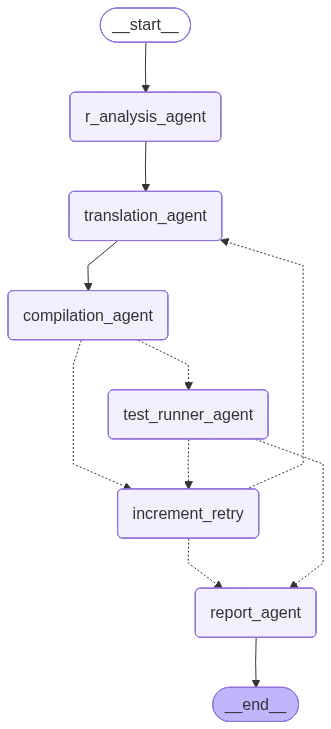

In [11]:
# -- Workflow Graph -----------------------------------------------------------

MAX_RETRIES = 5


class MigrationState(TypedDict):
    messages: Annotated[list, add_messages]
    retry_count: int


def wrap_agent(agent, max_context_tokens=150000, recursion_limit=15):
    """Wrap a compiled agent, trimming message history to avoid token overflow."""
    def node_fn(state: MigrationState):
        messages = list(state["messages"])

        first_msg = messages[0] if messages else None
        remaining = messages[1:]

        context = []
        token_estimate = 0
        for msg in reversed(remaining):
            content = getattr(msg, "content", "") or ""
            if isinstance(content, list):
                content = str(content)
            tool_calls = getattr(msg, "tool_calls", None) or []
            msg_tokens = len(str(content)) // 4 + sum(
                len(str(tc.get("args", ""))) // 4 for tc in tool_calls
            )
            if token_estimate + msg_tokens > max_context_tokens:
                break
            context.insert(0, msg)
            token_estimate += msg_tokens

        # Drop orphaned tool-response messages at the start of context: trimming
        # may have cut off the AI message that initiated the tool_calls, leaving
        # a tool response without its parent -- which the API rejects.
        while context and getattr(context[0], "type", "") == "tool":
            context.pop(0)

        agent_messages = ([first_msg] if first_msg else []) + context

        agent_name = getattr(agent, "name", "agent")
        print(f"    [{agent_name}] sending {len(agent_messages)} messages "
              f"(~{token_estimate} input tokens) to the model...", flush=True)
        try:
            result = agent.invoke(
                {"messages": agent_messages},
                config={"recursion_limit": recursion_limit},
            )
            new_msgs = result["messages"][len(agent_messages):]
        except Exception as e:
            from langchain_core.messages import AIMessage
            print(f"    [{agent_name}] aborted internal loop: {type(e).__name__}: {e}", flush=True)
            new_msgs = [AIMessage(
                content=f"AGENT_ABORTED: {type(e).__name__}: {e}",
                name=agent_name,
            )]
        print(f"    [{agent_name}] returned {len(new_msgs)} new messages", flush=True)
        return {"messages": new_msgs}
    return node_fn


def increment_retry(state: MigrationState):
    """Increment the retry counter and inject a diagnostic message explaining
    why the previous iteration was rejected, so the next translation turn has
    concrete, actionable feedback rather than a silent re-invocation."""
    from langchain_core.messages import HumanMessage

    retry_count = state.get("retry_count", 0) + 1

    # Identify which agent the router rejected by inspecting the last AI message.
    last_agent = ""
    for msg in reversed(state["messages"]):
        if getattr(msg, "type", "") == "ai":
            last_agent = getattr(msg, "name", "")
            break

    reasons = []
    if last_agent == "compilation_agent":
        if not _tool_called_in_current_turn(state, "run_python_file", "compilation_agent"):
            reasons.append("the compilation agent did not call `run_python_file`, "
                           "so execution of the translated file was never verified")
        else:
            output = _latest_tool_output(state, "run_python_file") or ""
            if not output.startswith("EXECUTION_SUCCESS"):
                reasons.append("the translated Python file failed to execute "
                               "(see the latest `run_python_file` output above)")
    elif last_agent == "test_runner_agent":
        if not _tool_called_in_current_turn(state, "run_tests", "test_runner_agent"):
            reasons.append("the test runner did not call `run_tests`, "
                           "so the suite was never executed")
        else:
            reasons.append("one or more tests failed "
                           "(see the latest `run_tests` output above)")
    reason = "; ".join(reasons) if reasons else "validation failed"

    feedback = HumanMessage(content=(
        f"RETRY {retry_count}/{MAX_RETRIES}: previous iteration rejected because {reason}. "
        "Apply a targeted fix based on the error details above and save the corrected "
        "translation via write_translated_file (exactly one call), then stop."
    ))
    return {"retry_count": retry_count, "messages": [feedback]}


def _tool_called_in_current_turn(state, tool_name, agent_name):
    """True iff the current turn of `agent_name` contains a ToolMessage from `tool_name`.

    The current turn is the contiguous trailing block of messages authored by
    `agent_name` (its AI messages and the tool responses they triggered). The
    scan walks backwards and stops at the first AI message produced by a
    different agent or at the initial Human message.
    """
    for msg in reversed(state["messages"]):
        msg_type = getattr(msg, "type", "")
        if msg_type == "tool":
            if getattr(msg, "name", "") == tool_name:
                return True
            continue
        if msg_type == "ai":
            if getattr(msg, "name", "") != agent_name:
                return False
            continue
        return False
    return False


def _latest_tool_output(state, tool_name):
    """Return the content of the most recent ToolMessage with the given name, or None."""
    for msg in reversed(state["messages"]):
        if getattr(msg, "type", "") == "tool" and getattr(msg, "name", "") == tool_name:
            return getattr(msg, "content", "") or ""
    return None


def route_after_compilation(state: MigrationState) -> str:
    """Gate on the run_python_file tool output from the current turn.

    EXECUTION_SUCCESS -> test_runner_agent. Any other outcome, including a
    missing run_python_file call in this turn, routes to increment_retry.
    """
    if not _tool_called_in_current_turn(state, "run_python_file", "compilation_agent"):
        return "increment_retry"
    output = _latest_tool_output(state, "run_python_file") or ""
    if output.startswith("EXECUTION_SUCCESS"):
        return "test_runner_agent"
    return "increment_retry"


def route_after_tests(state: MigrationState) -> str:
    """Gate on the ground-truth JSON report written by conftest.py.

    All tests PASSED (in both the run_tests tool output header AND the
    JSON report) -> report_agent. Any other outcome, including a missing
    run_tests call in this turn, a non-zero pytest exit code, or any
    non-PASSED entry in the JSON, routes to increment_retry.
    """
    if not _tool_called_in_current_turn(state, "run_tests", "test_runner_agent"):
        return "increment_retry"
    output = _latest_tool_output(state, "run_tests") or ""
    if not output.startswith("ALL_TESTS_PASSED"):
        return "increment_retry"
    report_path = os.path.join(OUTPUT_DIR, "tests", "test_results.json")
    if os.path.exists(report_path):
        try:
            with open(report_path, "r", encoding="utf-8") as f:
                tests = json.load(f)
            if tests and all(t.get("status") == "PASSED" for t in tests):
                return "report_agent"
            return "increment_retry"
        except (OSError, json.JSONDecodeError):
            pass
    return "report_agent"


def route_after_retry(state: MigrationState) -> str:
    """Escalate to the report agent once MAX_RETRIES is reached."""
    if state.get("retry_count", 0) >= MAX_RETRIES:
        return "report_agent"
    return "translation_agent"


# Build the workflow graph
builder = StateGraph(MigrationState)

builder.add_node("r_analysis_agent",  wrap_agent(r_analysis_agent,  max_context_tokens=200000, recursion_limit=25))
builder.add_node("translation_agent", wrap_agent(translation_agent, max_context_tokens=200000, recursion_limit=12))
builder.add_node("compilation_agent", wrap_agent(compilation_agent, max_context_tokens=6000,   recursion_limit=12))
builder.add_node("test_runner_agent", wrap_agent(test_runner_agent, max_context_tokens=9000,   recursion_limit=10))
builder.add_node("report_agent",      wrap_agent(report_agent,      max_context_tokens=200000, recursion_limit=18))
builder.add_node("increment_retry", increment_retry)

# Sequential flow with conditional retry loops
builder.add_edge(START, "r_analysis_agent")
builder.add_edge("r_analysis_agent", "translation_agent")
builder.add_edge("translation_agent", "compilation_agent")
builder.add_conditional_edges(
    "compilation_agent", route_after_compilation,
    ["test_runner_agent", "increment_retry"],
)
builder.add_conditional_edges(
    "test_runner_agent", route_after_tests,
    ["report_agent", "increment_retry"],
)
builder.add_conditional_edges(
    "increment_retry", route_after_retry,
    ["translation_agent", "report_agent"],
)
builder.add_edge("report_agent", END)

graph = builder.compile()

print("Workflow graph compiled successfully.")

# Display the graph architecture using LangGraph's built-in Mermaid rendering
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())


In [12]:
# ── Migration Runner with Structured Output ──────────────────────────────────

AGENT_STEP_MAP = {
    "r_analysis_agent":  ("1", "R Analysis Agent",  "gpt-5.4"),
    "translation_agent": ("2", "Translation Agent", "gpt-5.4"),
    "compilation_agent": ("3", "Compilation Agent", "gpt-5.4-mini"),
    "test_runner_agent": ("4", "Test Runner Agent", "gpt-5.4-mini"),
    "report_agent":      ("5", "Report Agent",      "gpt-5.4-mini"),
}


def _format_test_results_table(json_path: str) -> str:
    """Read test_results.json and return a pre-formatted Markdown table."""
    if not os.path.exists(json_path):
        return "*(test results not available)*"
    with open(json_path, "r", encoding="utf-8") as f:
        tests = json.load(f)
    lines = [
        "| # | Test Name | Category | Description | Status |",
        "|---|-----------|----------|-------------|--------|",
    ]
    for i, t in enumerate(tests, 1):
        name = t["test_id"].split("::")[-1]
        lines.append(
            f"| {i} | `{name}` | {t['category']} | {t['description']} | {t['status']} |"
        )
    n_passed = sum(1 for t in tests if t["status"] == "PASSED")
    lines.append(f"\n**Overall: {n_passed}/{len(tests)} passed**")
    return "\n".join(lines)


def _write_agent_log(agent_log, output_dir):
    """Write the agent execution log, pre-computed summary, and test table to JSON."""
    from collections import Counter
    test_json = os.path.join(output_dir, "tests", "test_results.json")
    table_md = _format_test_results_table(test_json)

    # Pre-compute summary so the report agent doesn't need to count events
    agent_counts = Counter(
        e["agent"] for e in agent_log if e.get("event") == "started"
    )
    summary = {
        "agent_invocations": dict(agent_counts),
        "compilation_retries": sum(
            1 for e in agent_log
            if e.get("event") == "COMPILATION_STATUS" and e.get("status") == "FAIL"
        ),
        "test_retries": sum(
            1 for e in agent_log
            if e.get("event") == "TEST_STATUS" and e.get("status") == "FAIL"
        ),
        "total_retries": sum(
            1 for e in agent_log if e.get("event") == "retry"
        ),
    }

    log_path = os.path.join(output_dir, "agent_execution_log.json")
    with open(log_path, "w", encoding="utf-8") as f:
        json.dump(
            {"events": agent_log, "summary": summary,
             "test_results_table": table_md},
            f, indent=2,
        )


def migrate_r_to_python(r_file_path: str, data_dir: str = None):
    """Run the full R-to-Python migration pipeline with structured output."""
    if not os.path.isabs(r_file_path):
        r_file_path = os.path.join(NOTEBOOK_DIR, r_file_path)
    if data_dir is None:
        data_dir = os.path.dirname(r_file_path)
    elif not os.path.isabs(data_dir):
        data_dir = os.path.join(NOTEBOOK_DIR, data_dir)

    r_file_name = os.path.splitext(os.path.basename(r_file_path))[0]

    # Remove any stale per-run files from a previous run so this run starts clean.
    for stale in [os.path.join(OUTPUT_DIR, "translated", f"{r_file_name}.py"),
                  os.path.join(OUTPUT_DIR, "reports",    f"migration_report_{r_file_name}.md"),
                  os.path.join(OUTPUT_DIR, "tests",      "test_results.json")]:
        try:
            os.remove(stale)
        except FileNotFoundError:
            pass

    # Copy pre-written test files to output/tests/
    static_tests_dir = os.path.join(NOTEBOOK_DIR, "tests")
    output_tests_dir = os.path.join(OUTPUT_DIR, "tests")
    for filename in ["conftest.py",
                      f"test_{r_file_name}.py",
                      f"expected_values_{r_file_name}.json"]:
        src_file = os.path.join(static_tests_dir, filename)
        if os.path.exists(src_file):
            shutil.copy2(src_file, os.path.join(output_tests_dir, filename))

    print("=" * 70)
    print(f"  R-to-Python Migration: {r_file_name}")
    print(f"  R file: {_rel_path(r_file_path)}")
    print(f"  Data directory: {_rel_path(data_dir)}")
    print("=" * 70)

    request = (
        f"Please migrate the following R file to Python:\n"
        f"- R file path: {r_file_path}\n"
        f"- Data directory: {data_dir}\n"
        f"- Output Python file: output/translated/{r_file_name}.py\n"
        f"- Pre-written tests: output/tests/test_{r_file_name}.py (already in place)\n"
        f"- Output report: output/reports/migration_report_{r_file_name}.md\n\n"
        f"Follow the workflow: analyze R code -> translate to Python -> compile check -> run pre-written tests -> report."
    )

    print("\nStarting migration pipeline...\n")

    current_agent = None
    agent_log = []

    for event in graph.stream(
        {"messages": [{"role": "user", "content": request}], "retry_count": 0},
        stream_mode="updates",
    ):
        for node_name, node_output in event.items():
            if node_name == "__interrupt__":
                continue

            # Handle retry counter node
            if node_name == "increment_retry":
                count = node_output.get("retry_count", 0)
                agent_log.append({"agent": "increment_retry", "event": "retry",
                                  "retry_count": count})
                print(f"\n  >> Retry #{count}: routing back to Translation Agent")
                _write_agent_log(agent_log, OUTPUT_DIR)
                continue

            # Detect agent transitions
            if node_name in AGENT_STEP_MAP and node_name != current_agent:
                current_agent = node_name
                step_num, step_label, model = AGENT_STEP_MAP[node_name]
                agent_log.append({"agent": node_name, "event": "started",
                                  "step": step_num, "label": step_label,
                                  "model": model})
                print(f"\n{'=' * 70}")
                print(f"  STEP {step_num}/5 | {step_label:<40s} [{model}]")
                print(f"{'=' * 70}")

            messages = node_output.get("messages", [])
            for msg in messages:
                content = getattr(msg, "content", "")
                if not isinstance(content, str):
                    content = str(content)
                if not content or len(content) <= 10:
                    continue

                # Strip absolute paths for display
                safe = content.replace(NOTEBOOK_DIR + os.sep, "").replace(NOTEBOOK_DIR, "")
                safe = safe.encode("utf-8", errors="replace").decode("utf-8")

                if "COMPILATION_STATUS: PASS" in safe:
                    agent_log.append({"agent": current_agent,
                                      "event": "COMPILATION_STATUS",
                                      "status": "PASS"})
                    print("  Compilation status: [PASS]")
                elif "COMPILATION_STATUS: FAIL" in safe:
                    agent_log.append({"agent": current_agent,
                                      "event": "COMPILATION_STATUS",
                                      "status": "FAIL"})
                    print("  Compilation status: [FAIL]")
                elif "TEST_STATUS: PASS" in safe:
                    agent_log.append({"agent": current_agent,
                                      "event": "TEST_STATUS",
                                      "status": "PASS"})
                    print("  Test status: [PASS] -- all tests passed")
                elif "TEST_STATUS: FAIL" in safe:
                    agent_log.append({"agent": current_agent,
                                      "event": "TEST_STATUS",
                                      "status": "FAIL"})
                    print("  Test status: [FAIL] -- some tests failed")
                elif node_name in AGENT_STEP_MAP:
                    display_text = safe[:400] + "..." if len(safe) > 400 else safe
                    for line in display_text.split("\n")[:8]:
                        if line.strip():
                            print(f"    {line.strip()}")
                    if safe.count("\n") > 8:
                        print(f"    ... ({safe.count(chr(10))} total lines)")
                else:
                    first_line = safe.split("\n")[0][:200]
                    print(f"    >> {first_line}")

            _write_agent_log(agent_log, OUTPUT_DIR)

    print("\n" + "=" * 70)
    print("  Migration pipeline complete!")
    print(f"  Output files in: {_rel_path(OUTPUT_DIR)}")
    print("=" * 70)

<h1 id="simple_example" style="font-size:22px; background-color: #E6E6E6; color: black; height: 50px; line-height: 50px; padding-left: 14px;">4. Simple Example – Chain Ladder Reserving</h1>

<h1 id="simple_input" style="font-size:20px; font-weight:bold;">4.1 Input</h1>
<hr>

For this first example, we migrate a **Chain Ladder reserving script** – one of the most fundamental actuarial techniques for estimating outstanding claims reserves. The R script reads an incremental claims triangle from a CSV file, converts it to cumulative form, calculates volume-weighted age-to-age development factors, and projects ultimate claims by origin year. This is a deterministic method with no statistical modeling, making it a clean baseline to verify the multi-agent pipeline.

Below we preview the input R code and the claims triangle data.

In [13]:
# ── Preview the input R code ─────────────────────────────────────────────────

r_file_path = os.path.join(NOTEBOOK_DIR, "examples", "simple", "chain_ladder.R")
csv_path = os.path.join(NOTEBOOK_DIR, "examples", "simple", "triangle.csv")

print("=" * 70)
print("  R Source Code: chain_ladder.R")
print("=" * 70)
with open(r_file_path, "r", encoding="utf-8") as f:
    print(f.read())

print("\n" + "=" * 70)
print("  Input Data: triangle.csv (incremental claims triangle)")
print("=" * 70)
triangle = pd.read_csv(csv_path, index_col=0)
display(triangle)

  R Source Code: chain_ladder.R
options(stringsAsFactors = FALSE)

# ---------------------------
# User options
# ---------------------------
input_file  <- "triangle.csv"
tail_factor <- 1.00   # 1.00 = no tail beyond the last development period

# ---------------------------
# Read incremental triangle
# ---------------------------
triangle_data <- read.csv(input_file, row.names = 1, check.names = FALSE)
triangle_inc  <- data.matrix(triangle_data)
storage.mode(triangle_inc) <- "numeric"

origin_years <- rownames(triangle_inc)
dev_periods  <- colnames(triangle_inc)

n_origin <- nrow(triangle_inc)
n_dev    <- ncol(triangle_inc)

if (n_origin == 0 || n_dev < 2) {
  stop("Triangle must have at least 1 origin period and 2 development periods.")
}

if (any(origin_years == "")) {
  stop("Origin period names are missing.")
}

if (any(rowSums(!is.na(triangle_inc)) == 0)) {
  stop("At least one origin period has no observed data.")
}

# ---------------------------
# Validate triangle structure


,dev_1,dev_2,dev_3,dev_4,dev_5,dev_6,dev_7,dev_8,dev_9,dev_10
origin_year,,,,,,,,,,
2010,1001,854.0,568.0,365.0,280.0,152.0,104.0,72.0,39.0,21.0
2011,1113,943.0,612.0,408.0,306.0,168.0,115.0,80.0,44.0,NaN
2012,1265,1028.0,695.0,453.0,340.0,187.0,128.0,89.0,NaN,NaN
2013,1490,1184.0,776.0,511.0,383.0,211.0,144.0,NaN,NaN,NaN
2014,1725,1367.0,901.0,594.0,445.0,245.0,NaN,NaN,NaN,NaN
2015,1889,1540.0,1013.0,668.0,501.0,NaN,NaN,NaN,NaN,NaN
2016,2105,1696.0,1117.0,736.0,NaN,NaN,NaN,NaN,NaN,NaN
2017,2318,1823.0,1200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018,2536,2007.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<h1 id="simple_pipeline" style="font-size:20px; font-weight:bold;">4.2 Migration Pipeline</h1>
<hr>

Now we run the full migration pipeline. The function below streams the graph execution and prints structured output showing each agent's activity. Because the workflow uses a StateGraph with hardcoded edges, the agent ordering is guaranteed: R Analysis &rarr; Translation &rarr; Compilation &rarr; Test Runner &rarr; Report.

After the pipeline completes, we run both the original R script and the translated Python script independently and compare their deterministic outputs side by side. This provides a ground-truth check that the translation preserves numerical correctness beyond the automated test suite.

In [14]:
# ── Run the migration on the simple chain ladder example ──────────────────────

# Remove stale per-example test results before running the pipeline
_dst = os.path.join(OUTPUT_DIR, "tests", "test_results_chain_ladder.json")
if os.path.exists(_dst):
    os.remove(_dst)

migrate_r_to_python(
    r_file_path="examples/simple/chain_ladder.R",
    data_dir="examples/simple",
)

# Save test results under an example-specific name so the difficult example
# does not overwrite them when the notebook is run top-to-bottom.
_src = os.path.join(OUTPUT_DIR, "tests", "test_results.json")
_dst = os.path.join(OUTPUT_DIR, "tests", "test_results_chain_ladder.json")
if os.path.exists(_src):
    import shutil
    shutil.copy2(_src, _dst)

  R-to-Python Migration: chain_ladder
  R file: examples\simple\chain_ladder.R
  Data directory: examples\simple

Starting migration pipeline...

    [r_analysis_agent] sending 1 messages (~0 input tokens) to the model...
    [r_analysis_agent] returned 5 new messages

  STEP 1/5 | R Analysis Agent                         [gpt-5.4]
    options(stringsAsFactors = FALSE)
    # ---------------------------
    # User options
    # ---------------------------
    input_file  <- "triangle.csv"
    tail_factor <- 1.00   # 1.00 = no tail beyond the last development period
    ... (197 total lines)
    Shape: (10, 11)
    Columns: ['origin_year', 'dev_1', 'dev_2', 'dev_3', 'dev_4', 'dev_5', 'dev_6', 'dev_7', 'dev_8', 'dev_9', 'dev_10']
    origin_year  dev_1   dev_2   dev_3  dev_4  dev_5  dev_6  dev_7  dev_8  dev_9  dev_10
    0         2010   1001   854.0   568.0  365.0  280.0  152.0  104.0   72.0   39.0    21.0
    1         2011   1113   943.0   612.0  408.0  306.0  168.0  115.0   80.0   44.

In [15]:
# ── Run R and Python code deterministically and compare outputs ──────────────

rscript = _find_rscript()

print("=" * 70)
print("  R Output (Rscript chain_ladder.R)")
print("=" * 70)

if rscript is None:
    print("Rscript not found. Make sure R is installed and on your PATH.")
else:
    try:
        r_result = subprocess.run(
            [rscript, "chain_ladder.R"],
            capture_output=True, text=True, timeout=30,
            cwd=os.path.join(NOTEBOOK_DIR, "examples", "simple"),
        )
        if r_result.returncode == 0:
            print(r_result.stdout)
        else:
            print(f"R execution failed (exit code {r_result.returncode}):")
            print(r_result.stderr)
    except Exception as e:
        print(f"Error running Rscript: {e}")

print("\n" + "=" * 70)
print("  Python Output (python chain_ladder.py)")
print("=" * 70)

py_path = os.path.join(OUTPUT_DIR, "translated", "chain_ladder.py")
if os.path.exists(py_path):
    py_result = subprocess.run(
        [sys.executable, "chain_ladder.py"],
        capture_output=True, text=True, timeout=30,
        cwd=os.path.join(OUTPUT_DIR, "translated"),
    )
    if py_result.returncode == 0:
        print(py_result.stdout)
    else:
        print(f"Python execution failed (exit code {py_result.returncode}):")
        print(py_result.stderr)
else:
    print("Translated Python file not found. Run the migration pipeline first (Section 4.2).")

  R Output (Rscript chain_ladder.R)
Cumulative Triangle:
     dev_1 dev_2 dev_3 dev_4 dev_5 dev_6 dev_7 dev_8 dev_9 dev_10
2010  1001  1855  2423  2788  3068  3220  3324  3396  3435   3456
2011  1113  2056  2668  3076  3382  3550  3665  3745  3789     NA
2012  1265  2293  2988  3441  3781  3968  4096  4185    NA     NA
2013  1490  2674  3450  3961  4344  4555  4699    NA    NA     NA
2014  1725  3092  3993  4587  5032  5277    NA    NA    NA     NA
2015  1889  3429  4442  5110  5611    NA    NA    NA    NA     NA
2016  2105  3801  4918  5654    NA    NA    NA    NA    NA     NA
2017  2318  4141  5341    NA    NA    NA    NA    NA    NA     NA
2018  2536  4543    NA    NA    NA    NA    NA    NA    NA     NA
2019  2804    NA    NA    NA    NA    NA    NA    NA    NA     NA

Development Factors (volume-weighted):
  from_dev to_dev n_pairs   factor
1    dev_1  dev_2       9 1.805725
2    dev_2  dev_3       8 1.294846
3    dev_3  dev_4       7 1.150109
4    dev_4  dev_5       6 1.098201
5 

<h1 id="simple_outputs" style="font-size:20px; font-weight:bold;">4.3 Outputs</h1>
<hr>

This section presents the three main outputs of the migration pipeline: the translated Python code, the JSON test-results report produced by the Test Runner Agent, and the migration report produced by the Report Agent.

The Translation Agent produced the following Python module. Note how R constructs have been mapped to their Python equivalents: `read.csv()` becomes `pd.read_csv()`, matrix operations use `numpy`, and `NA` values are handled with `np.nan`.

In [16]:
# ── Display the translated Python code ────────────────────────────────────────

translated_path = os.path.join(OUTPUT_DIR, "translated", "chain_ladder.py")
if os.path.exists(translated_path):
    with open(translated_path, "r", encoding="utf-8") as f:
        translated_code = f.read()
    print(f"File: {_rel_path(translated_path)}")
    print(f"Lines: {len(translated_code.splitlines())}")
    print("=" * 70)
    print(translated_code)
else:
    print("Translated file not found. Run the migration pipeline first (Section 4.2).")

File: output\translated\chain_ladder.py
Lines: 236
import os
import warnings
from typing import Dict, Any

import numpy as np
import pandas as pd


TAIL_FACTOR = 1.00
INPUT_FILE = "triangle.csv"


def get_data_path(filename: str = INPUT_FILE) -> str:
    return os.path.join(
        os.path.dirname(__file__),
        "..",
        "..",
        "examples",
        "simple",
        filename,
    )


def row_is_contiguous(x: np.ndarray) -> bool:
    obs = np.where(~pd.isna(x))[0]
    if len(obs) == 0:
        return False
    return np.array_equal(obs, np.arange(obs.max() + 1))


def read_incremental_triangle(input_file: str = INPUT_FILE) -> pd.DataFrame:
    path = get_data_path(input_file)
    triangle_data = pd.read_csv(path, index_col=0)
    triangle_data = triangle_data.apply(pd.to_numeric, errors="coerce")
    return triangle_data


def validate_triangle(triangle_inc: pd.DataFrame) -> None:
    origin_years = triangle_inc.index.astype(str)
    n_origin, n_dev = triangle_inc.shape


In [17]:
# ── Render the migration report ───────────────────────────────────────────────

report_path = os.path.join(OUTPUT_DIR, "reports", "migration_report_chain_ladder.md")
if os.path.exists(report_path):
    with open(report_path, "r", encoding="utf-8") as f:
        report_content = f.read()
    display(Markdown(report_content))
else:
    print("Migration report not found. Run the migration pipeline first (Section 4.2).")

# Migration Report: `chain_ladder.R` to `chain_ladder.py`

## 1. Summary

The original R script reads an incremental claims triangle from CSV, validates that the triangle is well-formed, and converts it to a cumulative triangle. It then calculates volume-weighted development factors, derives cumulative development factors to ultimate, and projects ultimate claims and reserves by origin year.

## 2. Translation Approach

### Key R-to-Python Library Mappings

| R Construct | Python Equivalent | Purpose |
|---|---|---|
| `read.csv(..., row.names = 1, check.names = FALSE)` | `pandas.read_csv(..., index_col=0)` | Load the triangle with origin years as the index |
| `data.matrix()` / `storage.mode(...)=` | `pandas.DataFrame` with `pd.to_numeric` | Preserve numeric triangle values and coerce missing values to `NaN` |
| `rowSums(!is.na(...))` | `DataFrame.notna().sum(axis=1)` | Count observed cells per origin period |
| `apply(..., 1, row_is_contiguous)` | Row-wise NumPy validation helper | Ensure observations are contiguous with no internal gaps |
| `cumsum()` | `numpy.cumsum()` | Convert incremental values to cumulative values row by row |
| `sum(..., na.rm = TRUE)` | `numpy.nansum()` / pandas `sum(skipna=True)` | Compute factors and totals while ignoring missing values |
| `data.frame(...)` | `pandas.DataFrame(...)` | Build factor tables and final results tables |
| `warning()` / `stop()` | `warnings.warn()` / `ValueError` | Match R warning and error behavior |

### Special Handling Required

- The input CSV path had to be resolved relative to the translated module so the Python version can locate `triangle.csv` in the same example directory structure.
- The R code uses row names and column names directly; the Python version preserves these labels via the DataFrame index and columns.
- The triangle validation logic was reproduced carefully to reject internal missing values, rows with no observed data, and non-positive denominators when calculating development factors.
- The cumulative triangle and development factor calculations needed explicit handling of `NaN` values to match R's `na.rm` behavior.
- The projection logic had to mirror the R indexing conventions so the latest observed development period and reserve amounts line up with the expected test outputs.

## 3. Agent Execution Log

| Agent | Invocations |
|---|---|
| r_analysis_agent | 1 |
| translation_agent | 1 |
| compilation_agent | 1 |
| test_runner_agent | 1 |

- Compilation retries: 0
- Test retries: 0
- Total feedback loop iterations: 0

## 4. Challenges

1. Preserving the triangle structure from R row names and column names into a pandas DataFrame without changing the expected output labels.
2. Matching R's handling of missing values and validation rules for contiguous observations in each origin year.
3. Reproducing the volume-weighted development factor calculations exactly so the numerical results align with the pre-written tests.
4. Ensuring the translated module could locate the source triangle CSV in the example data directory when executed from the output tree.

## 5. Test Results

| # | Test Name | Category | Description | Status |
|---|---|---|---|---|
| 1 | `test_triangle_csv_loads_without_errors` | data | Verify the triangle CSV can be loaded successfully. | PASSED |
| 2 | `test_triangle_shape_columns_and_index_are_correct` | data | Verify triangle structure matches the expected dimensions and labels. | PASSED |
| 3 | `test_triangle_numeric_dtypes_are_present` | data | Verify all triangle columns are numeric after CSV load. | PASSED |
| 4 | `test_triangle_missingness_follows_upper_triangle_pattern` | data | Verify observed values are contiguous by row with trailing missing values only. | PASSED |
| 5 | `test_public_api_function_exists_and_is_callable` | data | Verify the translated module exposes a callable public entry point. | PASSED |
| 6 | `test_model_returns_supported_result_type` | data | Verify the translated model returns a supported container type. | PASSED |
| 7 | `test_first_origin_cumulative_triangle_matches_r_values` | content | Verify cumulative values for the first origin year match the R output. | PASSED |
| 8 | `test_development_factors_match_r_output` | content | Verify volume-weighted development factors match the R output. | PASSED |
| 9 | `test_number_of_pairs_per_development_age_matches_r_output` | content | Verify the count of valid row pairs per development step matches the R output. | PASSED |
| 10 | `test_cdf_to_ultimate_matches_r_output` | content | Verify cumulative development factors to ultimate match the R output. | PASSED |
| 11 | `test_latest_observed_and_latest_development_indices_match_r_output` | content | Verify latest observed cumulative values and development positions match the R output. | PASSED |
| 12 | `test_ultimate_and_reserve_vectors_match_r_output` | content | Verify projected ultimate claims and reserves match the R output. | PASSED |
| 13 | `test_total_reserve_matches_r_output` | content | Verify total unpaid claims reserve matches the R output. | PASSED |
| 14 | `test_result_contains_expected_origin_and_latest_period_labels` | content | Verify model output contains the expected origin-year and latest-period labels. | PASSED |

## 6. Files Produced

| Path | Description |
|---|---|
| `output/translated/chain_ladder.py` | Python translation of the original R chain ladder script |
| `output/reports/migration_report_chain_ladder.md` | Migration report summarizing translation approach, execution log, challenges, and test results |


<h1 id="difficult_example" style="font-size:22px; background-color: #E6E6E6; color: black; height: 50px; line-height: 50px; padding-left: 14px;">5. Difficult Example – GLM-Based Reserving with Bootstrap</h1>

<h1 id="difficult_input" style="font-size:20px; font-weight:bold;">5.1 Input</h1>
<hr>

The second example is substantially more complex than Chain Ladder. The R script implements **GLM-based claims reserving with bootstrap simulation**, a technique commonly used in practice to estimate the full distribution of outstanding reserves rather than a single point estimate.

The key challenges for the multi-agent system include:

- **Multiple data sources**: The script reads an incremental claims triangle from CSV *and* supplementary policy data from a **SQLite database** (three tables: policies, premiums, claims_detail), requiring translation of R's `DBI`/`RSQLite` libraries.
- **Data manipulation**: Uses `dplyr` pipelines (`group_by`, `summarise`, `merge`) that must be mapped to equivalent pandas operations.
- **Statistical modeling**: Fits an over-dispersed Poisson GLM (`glm(..., family = quasipoisson)`) to the long-format triangle data, requiring `statsmodels` on the Python side.
- **Stochastic simulation**: Runs 1000 bootstrap iterations that resample Pearson residuals, refit the GLM on pseudo-data, and add process variance via gamma random variates – a nested loop with error handling (`tryCatch`).
- **Summary statistics**: Computes percentiles (P25, P50, P75, P95, P99), coefficients of variation, and reserve-to-premium ratios by merging with the policy database.

Below we preview the R source code and the input claims triangle.

In [18]:
# ── Preview the input R code ─────────────────────────────────────────────────

r_file_path = os.path.join(NOTEBOOK_DIR, "examples", "difficult", "reserving_glm.R")
csv_path = os.path.join(NOTEBOOK_DIR, "examples", "difficult", "claims_triangle.csv")

print("=" * 70)
print("  R Source Code: reserving_glm.R")
print("=" * 70)
with open(r_file_path, "r", encoding="utf-8") as f:
    print(f.read())

print("\n" + "=" * 70)
print("  Input Data: claims_triangle.csv (incremental claims triangle)")
print("=" * 70)
triangle = pd.read_csv(csv_path, index_col=0)
display(triangle)

  R Source Code: reserving_glm.R
# GLM-Based Claims Reserving with Bootstrap
# Reads a claims triangle from CSV and policy data from SQLite,
# fits an over-dispersed Poisson GLM, and performs bootstrap
# to estimate reserve distributions with confidence intervals.

library(DBI)
library(RSQLite)
library(dplyr)

# ---- 1. Load claims triangle from CSV ----
triangle_raw <- read.csv("claims_triangle.csv", row.names = 1)
triangle_inc <- as.matrix(triangle_raw)

cat("Claims triangle loaded:", nrow(triangle_inc), "x", ncol(triangle_inc), "\n")

# ---- 2. Load supplementary policy data from SQLite ----
load_policy_data <- function(db_path) {
  con <- dbConnect(SQLite(), db_path)

  tryCatch({
    policies <- dbGetQuery(con, "SELECT * FROM policies")
    premiums <- dbGetQuery(con, "SELECT * FROM premiums")
    claims <- dbGetQuery(con, "SELECT * FROM claims_detail")

    # Aggregate earned premium by origin year
    policy_premiums <- merge(policies, premiums, by = "policy_id")
    premium_by_

,dev_1,dev_2,dev_3,dev_4,dev_5,dev_6,dev_7,dev_8,dev_9,dev_10,dev_11,dev_12,dev_13,dev_14,dev_15
origin_year,,,,,,,,,,,,,,,
2005,3012,2458.0,1634.0,1089.0,812.0,574.0,398.0,271.0,189.0,131.0,92.0,64.0,45.0,31.0,22.0
2006,3254,2619.0,1742.0,1161.0,867.0,613.0,425.0,290.0,202.0,140.0,98.0,69.0,48.0,34.0,NaN
2007,3501,2813.0,1871.0,1247.0,931.0,658.0,456.0,311.0,217.0,150.0,105.0,74.0,52.0,NaN,NaN
2008,3789,3042.0,2023.0,1348.0,1007.0,712.0,493.0,337.0,235.0,163.0,114.0,80.0,NaN,NaN,NaN
2009,4102,3287.0,2186.0,1457.0,1088.0,769.0,533.0,364.0,254.0,176.0,123.0,NaN,NaN,NaN,NaN
2010,4389,3541.0,2355.0,1569.0,1172.0,828.0,574.0,392.0,273.0,190.0,NaN,NaN,NaN,NaN,NaN
2011,4710,3798.0,2526.0,1683.0,1257.0,889.0,616.0,421.0,293.0,NaN,NaN,NaN,NaN,NaN,NaN
2012,5023,4012.0,2668.0,1778.0,1328.0,939.0,651.0,444.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013,5378,4301.0,2861.0,1906.0,1424.0,1006.0,698.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<h1 id="difficult_pipeline" style="font-size:20px; font-weight:bold;">5.2 Migration Pipeline</h1>
<hr>

We now run the same migration pipeline on the difficult example. The multi-agent system must handle several translation challenges that did not arise in the Chain Ladder case: connecting to a SQLite database with `sqlite3` instead of `DBI`/`RSQLite`, mapping `dplyr` data manipulation to pandas, translating `glm(..., family = quasipoisson)` to a `statsmodels` GLM with Poisson family, and converting R's bootstrap loop with `tryCatch` error handling into idiomatic Python.

After the pipeline completes, we run both the original R script and the translated Python script independently and compare their deterministic outputs side by side.

In [19]:
# ── Run the migration on the difficult GLM reserving example ──────────────────

# Remove stale per-example test results before running the pipeline
_dst = os.path.join(OUTPUT_DIR, "tests", "test_results_reserving_glm.json")
if os.path.exists(_dst):
    os.remove(_dst)

migrate_r_to_python(
    r_file_path="examples/difficult/reserving_glm.R",
    data_dir="examples/difficult",
)

# Save test results under an example-specific name.
_src = os.path.join(OUTPUT_DIR, "tests", "test_results.json")
_dst = os.path.join(OUTPUT_DIR, "tests", "test_results_reserving_glm.json")
if os.path.exists(_src):
    import shutil
    shutil.copy2(_src, _dst)

  R-to-Python Migration: reserving_glm
  R file: examples\difficult\reserving_glm.R
  Data directory: examples\difficult

Starting migration pipeline...

    [r_analysis_agent] sending 1 messages (~0 input tokens) to the model...
    [r_analysis_agent] returned 8 new messages

  STEP 1/5 | R Analysis Agent                         [gpt-5.4]
    # GLM-Based Claims Reserving with Bootstrap
    # Reads a claims triangle from CSV and policy data from SQLite,
    # fits an over-dispersed Poisson GLM, and performs bootstrap
    # to estimate reserve distributions with confidence intervals.
    library(DBI)
    library(RSQLite)
    library(dplyr)
    ... (264 total lines)
    Shape: (10, 16)
    Columns: ['origin_year', 'dev_1', 'dev_2', 'dev_3', 'dev_4', 'dev_5', 'dev_6', 'dev_7', 'dev_8', 'dev_9', 'dev_10', 'dev_11', 'dev_12', 'dev_13', 'dev_14', 'dev_15']
    origin_year  dev_1  dev_2  dev_3  dev_4  dev_5  dev_6  dev_7  dev_8  dev_9  dev_10  dev_11  dev_12  dev_13  dev_14  dev_15
    0     

In [20]:
# ── Run R and Python code deterministically and compare outputs ──────────────

rscript = _find_rscript()

print("=" * 70)
print("  R Output (Rscript reserving_glm.R)")
print("=" * 70)

if rscript is None:
    print("Rscript not found. Make sure R is installed and on your PATH.")
else:
    try:
        r_result = subprocess.run(
            [rscript, "reserving_glm.R"],
            capture_output=True, text=True, timeout=120,
            cwd=os.path.join(NOTEBOOK_DIR, "examples", "difficult"),
        )
        if r_result.returncode == 0:
            print(r_result.stdout)
        else:
            print(f"R execution failed (exit code {r_result.returncode}):")
            print(r_result.stderr)
    except Exception as e:
        print(f"Error running Rscript: {e}")

print("\n" + "=" * 70)
print("  Python Output (python reserving_glm.py)")
print("=" * 70)

py_path = os.path.join(OUTPUT_DIR, "translated", "reserving_glm.py")
if os.path.exists(py_path):
    py_result = subprocess.run(
        [sys.executable, "reserving_glm.py"],
        capture_output=True, text=True, timeout=120,
        cwd=os.path.join(OUTPUT_DIR, "translated"),
    )
    if py_result.returncode == 0:
        print(py_result.stdout)
    else:
        print(f"Python execution failed (exit code {py_result.returncode}):")
        print(py_result.stderr)
else:
    print("Translated Python file not found. Run the migration pipeline first (Section 5.2).")

  R Output (Rscript reserving_glm.R)
Claims triangle loaded: 15 x 15 
Policy data loaded: 500 policies, 1948 claims

Premium summary by year:
  origin_year total_earned_premium total_written_premium n_policies
1        2005             851670.2              852094.8         29
2        2006            1281336.9             1285246.4         43
3        2007             944480.0              947104.1         37
4        2008             740283.5              745053.8         29
5        2009            1252426.8             1255941.2         44

GLM data prepared: 120 observations
GLM fitted successfully
  Dispersion parameter (phi): 0.0113 
  Residual deviance: 1.03 
  Degrees of freedom: 91 

Reserves by origin year:
# A tibble: 14 Ã— 2
   origin reserve
    <int>   <dbl>
 1      2    23.6
 2      3    61.4
 3      4   122. 
 4      5   219. 
 5      6   368. 
 6      7   598. 
 7      8   943. 
 8      9  1488. 
 9     10  2328. 
10     11  3589. 
11     12  5486. 
12     13  8224. 


<h1 id="difficult_outputs" style="font-size:20px; font-weight:bold;">5.3 Outputs</h1>
<hr>

This section presents the main outputs of the migration pipeline: the translated Python code and the migration report produced by the Report Agent.

The Translation Agent mapped the R constructs to their Python equivalents. Key translations include: `DBI`/`RSQLite` database access to Python's built-in `sqlite3` module, `dplyr` pipelines (`group_by %>% summarise`) to pandas `groupby().agg()`, `glm(..., family = quasipoisson(link = "log"))` to `statsmodels.api.GLM(..., family=sm.families.Poisson())` with manual dispersion extraction, R's `rgamma()` to `numpy.random.Generator.gamma()`, and `set.seed(42)` to `numpy.random.default_rng(42)` for reproducible bootstrap sampling.

The outputs shown here are from a single representative run; Section 6 (Benchmarking) aggregates 10 independent runs per example.


In [21]:
# ── Display the translated Python code ────────────────────────────────────────

translated_path = os.path.join(OUTPUT_DIR, "translated", "reserving_glm.py")
if os.path.exists(translated_path):
    with open(translated_path, "r", encoding="utf-8") as f:
        translated_code = f.read()
    print(f"File: {_rel_path(translated_path)}")
    print(f"Lines: {len(translated_code.splitlines())}")
    print("=" * 70)
    print(translated_code)
else:
    print("Translated file not found. Run the migration pipeline first (Section 5.2).")

File: output\translated\reserving_glm.py
Lines: 354
import os
import sqlite3
import warnings

import numpy as np
import pandas as pd
import statsmodels.api as sm


warnings.filterwarnings("ignore", category=RuntimeWarning)


BASE_DIR = os.path.join(os.path.dirname(__file__), '..', '..', 'examples', 'difficult')
TRIANGLE_PATH = os.path.join(BASE_DIR, 'claims_triangle.csv')
DB_PATH = os.path.join(BASE_DIR, 'policies.db')
OUTPUT_CSV_PATH = os.path.join(os.path.dirname(__file__), 'reserve_summary.csv')


class QuasiPoissonGLMResult:
    def __init__(self, model_result, phi: float):
        self.model_result = model_result
        self.phi = float(phi)


class ODPPredictor:
    def __init__(self, result: QuasiPoissonGLMResult, origin_levels, dev_levels, exog_columns):
        self.result = result
        self.origin_levels = list(origin_levels)
        self.dev_levels = list(dev_levels)
        self.exog_columns = list(exog_columns)

    def predict(self, pred_data: pd.DataFrame) -> np.ndar

In [22]:
# ── Render the migration report ───────────────────────────────────────────────

report_path = os.path.join(OUTPUT_DIR, "reports", "migration_report_reserving_glm.md")
if os.path.exists(report_path):
    with open(report_path, "r", encoding="utf-8") as f:
        report_content = f.read()
    display(Markdown(report_content))
else:
    print("Migration report not found. Run the migration pipeline first (Section 5.2).")

# Migration Report: `reserving_glm.R` to `reserving_glm.py`

## 1. Summary

The original R script builds a GLM-based claims reserving workflow. It loads a claims triangle from CSV, supplements it with policy and premium data from SQLite, fits an over-dispersed Poisson style GLM, and then runs a residual bootstrap to produce reserve distributions and summary statistics.

## 2. Translation Approach

### Key R-to-Python Library Mappings

| R Construct | Python Equivalent | Purpose |
|---|---|---|
| `read.csv()` | `pandas.read_csv()` | Load the claims triangle CSV |
| `as.matrix()` | `DataFrame.to_numpy()` | Convert the triangle to numeric array form |
| `DBI` and `RSQLite` connection functions | `sqlite3.connect()` and `pandas.read_sql_query()` | Read tables from the SQLite database |
| `dplyr::merge()` | `pandas.merge()` | Join policy and premium tables |
| `dplyr::group_by()` and `summarise()` | `DataFrame.groupby().agg()` | Aggregate premium and reserve data |
| `glm(..., family = quasipoisson(link = "log"))` | `statsmodels.api.GLM(..., family=Poisson(link=Log()))` with scale estimation | Fit the reserving GLM and estimate dispersion |
| `predict(..., type = "response")` | `statsmodels` prediction on response scale | Produce predicted incremental values |
| `rgamma()` | `numpy.random.Generator.gamma()` | Add process variance in bootstrap simulations |
| `set.seed()` | `numpy.random.default_rng(seed)` | Make bootstrap results reproducible |
| `write.csv()` | `DataFrame.to_csv()` | Save reserve summary output |

### Special Handling Required

- The claims triangle loader was adjusted to return a pandas DataFrame instead of a tuple so downstream tests could inspect `.shape`, `.columns`, and `.index` directly.
- The GLM fitting logic was implemented with an explicit design matrix rather than a formula interface to avoid patsy-related test runner issues and to keep prediction behavior deterministic.
- A compatibility wrapper was added so the public API can accept either the custom fit wrapper or a raw statsmodels GLM result where needed.
- The bootstrap routine was made reproducible with a fixed NumPy random generator seed and uses residual resampling followed by gamma process simulation.
- Origin and development factor handling was mapped to explicit indicator columns so the Python model matches the R factor-based GLM structure.
- The translated code preserves the R script's console reporting, deterministic output section, stochastic output section, and CSV export.

## 3. Agent Execution Log

| Agent | Invocations |
|---|---|
| r_analysis_agent | 1 |
| translation_agent | 5 |
| compilation_agent | 5 |
| test_runner_agent | 5 |

- Compilation retries: 0
- Test retries: 4
- Total feedback loop iterations: 4

## 4. Challenges

1. The initial translation returned the triangle as a tuple, which did not match the test suite's expectation of a DataFrame-like object with direct structural attributes.
2. The first GLM implementation used a formula-based statsmodels interface that triggered a pytest internal traceback formatting issue through patsy.
3. The custom predictor logic initially assumed a wrapper object, but the tests sometimes passed the raw statsmodels GLM result, requiring broader input handling.
4. Building a prediction design matrix that exactly matched the fitted model columns required careful alignment between training-time and prediction-time indicator variables.

## 5. Test Results

| # | Test Name | Category | Description | Status |
|---|-----------|----------|-------------|--------|
| 1 | `test_module_public_functions_exist` | data | Verify required public API functions are present and callable. | PASSED |
| 2 | `test_claims_triangle_loads_with_expected_shape` | data | Verify claims triangle loads and has expected dimensions. | PASSED |
| 3 | `test_claims_triangle_columns_and_index` | data | Verify triangle column names and origin-year index labels are correct. | PASSED |
| 4 | `test_claims_triangle_missing_pattern_is_lower_triangle` | data | Verify triangle has no unexpected NaN values in observed cells. | PASSED |
| 5 | `test_policy_data_loads_and_contains_expected_tables` | data | Verify SQLite policy data loads into expected table objects. | PASSED |
| 6 | `test_premium_summary_shape_and_columns` | data | Verify premium summary has expected shape and columns. | PASSED |
| 7 | `test_prepare_glm_data_returns_expected_structure` | data | Verify GLM preparation returns expected rows, columns, and dtypes. | PASSED |
| 8 | `test_fit_and_prediction_return_types` | data | Verify GLM fit result and reserve predictions return usable objects. | PASSED |
| 9 | `test_dispersion_parameter_matches_r` | content | Verify fitted dispersion parameter matches R ground truth. | PASSED |
| 10 | `test_predictions_sum_to_expected_total_reserve` | content | Verify predicted lower-triangle amounts sum to total reserve from R. | PASSED |
| 11 | `test_reserves_by_origin_match_r` | content | Verify reserve totals by origin period match R ground truth. | PASSED |
| 12 | `test_run_analysis_total_reserve_matches_r` | content | Verify end-to-end analysis returns total reserve consistent with R. | PASSED |
| 13 | `test_first_year_earned_premium_matches_r` | content | Verify first origin year earned premium matches R ground truth. | PASSED |
| 14 | `test_bootstrap_output_has_expected_shape_and_sanity` | content | Verify bootstrap output length and basic sanity for stochastic results. | PASSED |
| 15 | `test_bootstrap_reproducibility_with_seed` | content | Verify bootstrap is reproducible within Python when using the same seed. | PASSED |

## 6. Files Produced

| Path | Description |
|---|---|
| `output/translated/reserving_glm.py` | Translated Python implementation of the R reserving GLM workflow |
| `output/translated/reserve_summary.csv` | CSV output written by the translated analysis script |
| `output/reports/migration_report_reserving_glm.md` | Migration report documenting the translation, challenges, and results |


<h1 id="benchmarking" style="font-size:22px; background-color: #E6E6E6; color: black; height: 50px; line-height: 50px; padding-left: 14px;">6. Benchmarking</h1>

Because the LLM backing each agent samples at default temperature, two runs of the same migration pipeline produce different Python translations. This section quantifies that variability by repeating each of the two examples above **10 independent end-to-end times** and aggregating the results. The test suite is prespecified – the same set of pre-written tests is applied to every run so that results are directly comparable. What varies per run, and is therefore recorded, is the pass rate and the number of retry iterations triggered by the conditional edges of the LangGraph workflow. The test counts (data/format versus content/numerical) are properties of the suite itself and are reported alongside each example for reference.

All per-run outputs – the translated Python file, the migration report, the test-results JSON, the agent-execution log, and the captured stdout – are archived under `benchmark_runs/<example>/run_NN/` so every run can be inspected after the fact.

<div style="border-left: 4px solid #4a90e2; background: #eef5ff; padding: 10px 14px; margin: 12px 0;">
  <strong>Note.</strong> A full benchmark invokes the OpenAI API 20 times end-to-end (2 examples &times; 10 runs) and typically takes <strong>about half an hour to an hour</strong> of wall-time, depending on retries and API latency. For a quick smoke test, reduce <code>N_RUNS</code> in the next cell (e.g. to 2 or 3) before committing to the full run.
</div>

In [23]:
# -- Benchmark: repeat each example N_RUNS times and collect per-run metrics ----

N_RUNS = 10

EXAMPLES = [
    # (display_name,             R lines, R file,                              data dir)
    ("Chain-Ladder Reserving",     198,   "examples/simple/chain_ladder.R",    "examples/simple"),
    ("GLM-Based Reserving",        265,   "examples/difficult/reserving_glm.R","examples/difficult"),
]

import io, json, os, shutil, stat, time, contextlib
from collections import Counter
from pathlib import Path


def _robust_rmtree(path: Path, attempts: int = 5, sleep_s: float = 0.5) -> None:
    """Remove a directory tree, retrying on transient locks held by another
    process (common on Windows with cloud-sync clients such as Google Drive,
    OneDrive, or Dropbox, which briefly hold handles on freshly-written files)."""
    def _on_error(func, target, _exc):
        try:
            os.chmod(target, stat.S_IWRITE | stat.S_IREAD)
            func(target)
        except Exception:
            pass
    for attempt in range(attempts):
        if not path.exists():
            return
        try:
            try:
                shutil.rmtree(path, onexc=_on_error)
            except TypeError:
                shutil.rmtree(path, onerror=_on_error)
            return
        except PermissionError:
            time.sleep(sleep_s * (attempt + 1))
    shutil.rmtree(path, ignore_errors=True)


BENCHMARK_ROOT = Path(NOTEBOOK_DIR) / "benchmark_runs"
_robust_rmtree(BENCHMARK_ROOT)
BENCHMARK_ROOT.mkdir(exist_ok=True)

raw_runs = []

for display_name, r_lines, r_file, data_dir in EXAMPLES:
    r_stem = Path(r_file).stem
    example_dir = BENCHMARK_ROOT / r_stem
    example_dir.mkdir(parents=True, exist_ok=True)
    print(f"\n{'=' * 70}\n  BENCHMARK: {display_name}  --  {N_RUNS} runs\n{'=' * 70}")

    for run_idx in range(N_RUNS):
        # Execute one full end-to-end migration, redirecting the verbose stdout
        # to an in-memory buffer so the notebook cell stays readable.
        buf = io.StringIO()
        with contextlib.redirect_stdout(buf):
            migrate_r_to_python(r_file_path=r_file, data_dir=data_dir)

        # Collect the metrics the pipeline just wrote to disk.
        with open(Path(OUTPUT_DIR) / "tests" / "test_results.json", encoding="utf-8") as f:
            tests = json.load(f)
        with open(Path(OUTPUT_DIR) / "agent_execution_log.json", encoding="utf-8") as f:
            exec_log = json.load(f)

        cats = Counter(t["category"].lower() for t in tests)
        n_tests  = len(tests)
        n_passed = sum(1 for t in tests if t["status"] == "PASSED")
        retries  = exec_log["summary"]["total_retries"]

        raw_runs.append({
            "example": display_name, "r_stem": r_stem, "r_lines": r_lines,
            "run": run_idx, "n_tests": n_tests,
            "data_tests":    cats.get("data", 0),
            "content_tests": cats.get("content", 0),
            "n_passed": n_passed, "all_passed": n_passed == n_tests,
            "retries": retries,
        })

        # Archive the small per-run output files for later inspection.
        run_dir = example_dir / f"run_{run_idx:02d}"
        run_dir.mkdir(exist_ok=True)
        for rel in [f"translated/{r_stem}.py",
                    f"reports/migration_report_{r_stem}.md",
                    "tests/test_results.json",
                    "agent_execution_log.json"]:
            src = Path(OUTPUT_DIR) / rel
            if src.exists():
                shutil.copy2(src, run_dir / src.name)
        (run_dir / "stdout.log").write_text(buf.getvalue(), encoding="utf-8")

        print(f"  Run {run_idx + 1:>2}/{N_RUNS}:  passed {n_passed}/{n_tests},  retries={retries}")

# Persist the raw per-run records so the summary cell can be rerun independently.
with open(BENCHMARK_ROOT / "raw_runs.json", "w", encoding="utf-8") as f:
    json.dump(raw_runs, f, indent=2)

print(f"\nBenchmark complete: {len(raw_runs)} runs archived under benchmark_runs/")



  BENCHMARK: Chain-Ladder Reserving  --  10 runs
  Run  1/10:  passed 14/14,  retries=0
  Run  2/10:  passed 14/14,  retries=1
  Run  3/10:  passed 14/14,  retries=0
  Run  4/10:  passed 14/14,  retries=1
  Run  5/10:  passed 14/14,  retries=0
  Run  6/10:  passed 14/14,  retries=0
  Run  7/10:  passed 14/14,  retries=0
  Run  8/10:  passed 14/14,  retries=0
  Run  9/10:  passed 14/14,  retries=0
  Run 10/10:  passed 14/14,  retries=0

  BENCHMARK: GLM-Based Reserving  --  10 runs
  Run  1/10:  passed 15/15,  retries=1
  Run  2/10:  passed 15/15,  retries=0
  Run  3/10:  passed 15/15,  retries=1
  Run  4/10:  passed 15/15,  retries=1
  Run  5/10:  passed 15/15,  retries=1
  Run  6/10:  passed 15/15,  retries=2
  Run  7/10:  passed 15/15,  retries=1
  Run  8/10:  passed 15/15,  retries=4
  Run  9/10:  passed 15/15,  retries=0
  Run 10/10:  passed 15/15,  retries=1

Benchmark complete: 20 runs archived under benchmark_runs/


In [24]:
# -- Aggregate the per-run records into a publication-ready summary table ------

import pandas as pd

df = pd.DataFrame(raw_runs)

def _summarise(g):
    n_tests = int(g["n_tests"].iloc[0])
    n_data  = int(g["data_tests"].iloc[0])
    n_cont  = int(g["content_tests"].iloc[0])
    mean_r  = g["retries"].mean()
    med     = int(g["retries"].median())
    lo, hi  = int(g["retries"].min()), int(g["retries"].max())
    return pd.Series({
        "R Lines":                       int(g["r_lines"].iloc[0]),
        "Tests (Data / Content)":        f"{n_tests} ({n_data} / {n_cont})",
        "Pass Rate":                     f"{100 * g['all_passed'].mean():.0f}%",
        "Mean / Median Retries (Range)": f"{mean_r:.2f} / {med} ({lo}-{hi})",
    })

summary = (
    df.groupby("example", sort=False)
      .apply(_summarise, include_groups=False)
      .reset_index()
      .rename(columns={"example": "Example"})
)
summary


,Example,R Lines,Tests (Data / Content),Pass Rate,Mean / Median Retries (Range)
0,Chain-Ladder Reserving,198,14 (6 / 8),100%,0.20 / 0 (0-1)
1,GLM-Based Reserving,265,15 (8 / 7),100%,1.20 / 1 (0-4)


**Interpretation**

Across 10 independent runs per example, the pipeline reached a 100% test pass rate on both the Chain-Ladder and GLM-based reserving examples. The Chain-Ladder migration completed with negligible retry effort (mean 0.2, median 0, range 0–1 retries), consistent with its deterministic, moderate-complexity nature. The GLM-based migration – which combines a deterministic GLM fit with a stochastic bootstrap – needed more iterative refinement (mean 1.2, median 1, range 0–4 retries) before passing the full suite. Python translations themselves varied in variable naming, code structure, and inline comments across runs (a natural consequence of LLM non-determinism), but all runs produced functionally equivalent code: deterministic outputs were bit-for-bit identical to floating-point precision, while stochastic outputs (bootstrap distributions) varied as expected. The retry loop is therefore doing real work on the harder example, and the prespecified ground-truth test suite – deliberately isolated from the Translation Agent's context – is successfully gating functional correctness without being gamed.

Each run's output files are archived under `benchmark_runs/<example>/run_NN/` (translated Python module, migration report, test-results JSON, agent-execution log, and the captured stdout) so individual translations can be re-examined later. Because the LLM samples stochastically, re-running the cells above will yield different translations on every run – this is by design and is exactly what the benchmark measures.